
# Simulation of the Hybrid TVB : the cerebellar use-case

## Zebrin plus

Simulation of the **large-scale dynamics of the cerebellar cortex** [1].

The **input SC** is loaded as a *weigth matrix*, including the axonal boundles connecting pair of regions, and *tract lengths matrix* as the lenghs of these boundels, prividing a the distnace beteween inter-connected regions. Here an engineered-curated SC was upload to account for specific-cerebellar structural connectivity, with mesoscale-derived parameters (i.e., the synaptic convergence) merged with macroscale, MRI-based parameters [2]. This is an hot-topic and further works on the SC curation are ongoin!!!

The **cerebellar MFM model** is defined as a python-class exploiting the modular software architecture of TVB[3].

The cerebellar MFM is used to extract the cerebellar cortical **firing rate**. The firing rate is the generative signal for the BOLD signal, recorded with **fMRI experiments** [2].

Here, a cerebellar cortical activity was simulated, considering 27 regions extracted from SUIT Atlas. The rate-based activtiy is then convolved with a hemodyanmic response function to generate the BOLD signal.

**Contents**

|Section | Content|
|---|---|
| 1 | Setup Colab: mount Drive, import of python libraries |
| 2 | Simulation configuration: simulation id, params, seed... |
| 3 | Upload of the input: the engineered-curated SC |
| 4 | Definition of a new model: `crbl_cortical_first_ord` |
| 5 | Theoretical model exploration|
| 6 | Settin of TVB specifics (coupling, integrator, monitor, stimulus) |
| 7 | Construction of the TVB `Simulator` |
| 8 | Save the paramaters: `parameter.json` |
| 9 | Run Simulation: Firing rate and BOLD signal |
| 10 | Check the results|


**Refs.:**

[1] Lorenzi et al., *PLoS Comput Biol*, 2023.

[2] Lorenzi et al., *NPJ System Biology and Applications*, 2025.

[3] SanzLeon et al., *Front Neruoinform*, 2013

*Other useful references*
- E-GLIF: Geminiani et al 2018, 2019 (https://doi.org/10.3389/fninf.2018.00088 and https://doi.org/10.3389/fncom.2019.00035)
- Mathematics: Boustani and Destexhe 2009 (https://doi.org/10.1162/neco.2009.02-08-710)
- TF formalism: Zerlaut et al. 2018 (https://doi.org/10.1007/s10827-017-0668-2)
- TF Fitting procedure: Zerlaut et al. 2016  (https://doi.org/10.1113/JP272317)
- MF with adaptation: Di Volo et al. 2019 (https://doi.org/10.1162/neco_a_01173)
- MF review for different neuron model: Carlu et al. 2020 (https://doi.org/10.1152/jn.00399.2019)



---
## 1. Setup Colab.
> Run this cell to import the required software packages, including tvb.

In [ ]:

# ----------------------------------------------------------------------------
# 1a. Install dependencies (only if missing) ----------------------------------
# ----------------------------------------------------------------------------
try:
    import tvb.simulator.lab  # noqa: F401
    print('tvb-library already installed')
except ImportError:
    print('installing tvb-library ...')
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'tvb-library'], check=True)
    print('>>> If Colab asks to restart the runtime: restart and re-run this cell.')

try:
    import numba  # noqa: F401
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'numba'], check=True)

# ----------------------------------------------------------------------------
# 1b. Mount Google Drive ------------------------------------------------------
# ----------------------------------------------------------------------------
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    print('Not running in Colab: skipping Drive mount.')

# ----------------------------------------------------------------------------
# 1c. Imports -----------------------------------------------------------------
# ----------------------------------------------------------------------------
import os
import json
import time

import numpy as np
import numpy.random as rgn
import matplotlib.pyplot as plt

import scipy.special as sp_spec
from numba import jit

# TVB
import tvb
import tvb.simulator.lab as lab
from tvb.simulator.models.base import Model, numpy   # TVB's numpy, used in the model class body
from tvb.basic.neotraits.api import NArray, Range, Final, List

print('TVB   :', getattr(tvb, '__version__', 'n/a'))
print('numpy :', np.__version__)

installing tvb-library ...
>>> If Colab asks to restart the runtime: restart and re-run this cell.
Mounted at /content/drive


/usr/local/lib/python3.13/dist-packages/tvb/datatypes/surfaces.py:60: UserWarning: Geodesic distance module is unavailable; some functionality for surfaces will be unavailable.
  warnings.warn(msg)


TVB   : n/a
numpy : 2.1.3



---
## 2. Simulation parameters

Here you set up the location where simulations will be stored. Simulation will be saved with a SIM_NAME set by the user, concatenated with the timestamp to avoid overwriting of the data.

You define also simulation parameters as:
- Number of regions, which must matched the parcellation you are using (i.e., raw/col of the SC)
- Simulation length and the integration step
- Stimulus onset (not intended to be used here --- some tuning required!)

In [ ]:

# -----------------------------------------------------------------------------
# Working directory: the folder holding this notebook and the SC zip file
# -----------------------------------------------------------------------------
if IN_COLAB:
    WORK_DIR = '/content/drive/MyDrive/EITN_school_2026_MFM/Day5'      # <-- EDIT to match your Drive path
else:
    WORK_DIR = os.getcwd()                                             # <-- EDIT to match your local path

SC_ZIP_NAME = 'SC_dirCB_ONLYCRBL.zip'
SC_PATH     = os.path.join(WORK_DIR, SC_ZIP_NAME)


# ----------------------------------------------------------------------------
# Simulation name (id set by the user and output folder + date and time) and
# Output folder creation
# ----------------------------------------------------------------------------
SIM_NAME = 'parallel_ONLYcrbl'

OUTPUT_FOLDER = os.path.join(WORK_DIR, 'TVB_output')

date_time = time.strftime("%Y%m%d_%H%M%S")
simname   = date_time + SIM_NAME + '_crbl_sim'

RESULT_DIR = os.path.join(OUTPUT_FOLDER, simname)
os.makedirs(RESULT_DIR, exist_ok=True)

print('Working dir     :', WORK_DIR)
print('SC file         :', SC_PATH, ' found' if os.path.exists(SC_PATH) else 'NOT FOUND')
print('Output folder   :', OUTPUT_FOLDER)
print('Simulation name :', simname)


# ----------------------------------------------------------------------------
# Time settings of the simulation
# ----------------------------------------------------------------------------
N_REGIONS = 27           # number of nodes in the cerebellar SC
SIM_LEN   = 120000.      #360000.      # simulation length [ms]  (use 5000. for a quick test)
DT = 0.5
CUT_TRANS = 2500.        # transient [ms], used to place the stimulus onset
MY_SEED   = 10           # random seed (for reproducibility)



Working dir     : /content/drive/MyDrive/EITN_school_2026_MFM/Day5
SC file         : /content/drive/MyDrive/EITN_school_2026_MFM/Day5/SC_dirCB_ONLYCRBL.zip  found
Output folder   : /content/drive/MyDrive/EITN_school_2026_MFM/Day5/TVB_output
Simulation name : 20260928_221725parallel_ONLYcrbl_crbl_sim



---
## 3. Structural Connectivity

Connectivity.from_file() reads the .zip file in the standard TVB format (weights.txt, tract_lengths.txt, centres.txt), with the labels taken from the first column of centres.txt.

The SC is already normalized during its creation; therefore, **no additional normalization** is applied. The conduction velocity is fixed at speed = 3.0 mm/ms.

In [ ]:
CONDUCTION_SPEED = 3.0   # [mm/ms]

connection = lab.connectivity.Connectivity().from_file(SC_PATH)
connection.speed = np.array(CONDUCTION_SPEED)
connection.configure()

# Let's have a look on what's inside the SC
print('Number of regions :', connection.number_of_regions)
print('weights           :', connection.weights.shape,
      '| min %.4f  max %.4f' % (connection.weights.min(), connection.weights.max()))
print('tract_lengths     :', connection.tract_lengths.shape,
      '| max %.2f mm' % connection.tract_lengths.max())
print('speed             :', connection.speed, 'mm/ms')
print('max delay         : %.2f ms' % connection.delays.max())
print('\nRegions:')
for i, lbl in enumerate(connection.region_labels):
    print('  %2d  %s' % (i, lbl))



2026-09-28 22:17:29,735 - WARNING - tvb.basic.readers - File 'average_orientations' not found in ZIP.
2026-09-28 22:17:29,736 - WARNING - tvb.basic.readers - File 'cortical' not found in ZIP.
2026-09-28 22:17:29,737 - WARNING - tvb.basic.readers - File 'hemispheres' not found in ZIP.
2026-09-28 22:17:29,740 - WARNING - tvb.basic.readers - File 'areas' not found in ZIP.
Number of regions : 27
weights           : (27, 27) | min 0.0000  max 0.5641
tract_lengths     : (27, 27) | max 106.12 mm
speed             : 3.0 mm/ms
max delay         : 35.37 ms

Regions:
   0  Left_I_IV
   1  Left_V
   2  Left_VI
   3  Left_CrusI
   4  Left_CrusII
   5  Left_VIIb
   6  Left_VIIIa
   7  Left_VIIIb
   8  Left_IX
   9  Left_X
  10  Vermis_VI
  11  Vermis_CrusII
  12  Vermis_VIIb
  13  Vermis_VIIIa
  14  Vermis_VIIIb
  15  Vermis_IX
  16  Vermis_X
  17  Right_I_IV
  18  Right_V
  19  Right_VI
  20  Right_CrusI
  21  Right_CrusII
  22  Right_VIIb
  23  Right_VIIIa
  24  Right_VIIIb
  25  Right_IX
  26  Ri

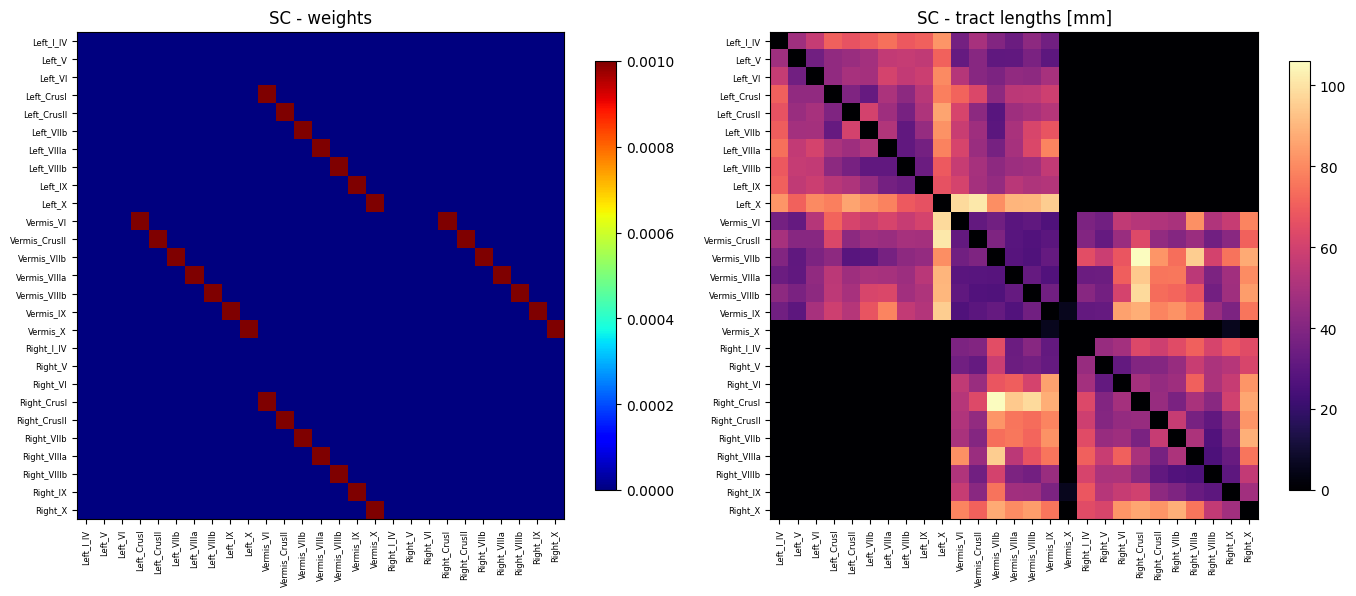

In [ ]:
# Structural connectivity overview
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
im0 = ax[0].imshow(connection.weights, cmap='jet', vmax = 0.001)
ax[0].set_title('SC - weights'); plt.colorbar(im0, ax=ax[0], shrink=0.8)
im1 = ax[1].imshow(connection.tract_lengths, cmap='magma')
ax[1].set_title('SC - tract lengths [mm]'); plt.colorbar(im1, ax=ax[1], shrink=0.8)
for a in ax:
    a.set_xticks(range(connection.number_of_regions))
    a.set_yticks(range(connection.number_of_regions))
    a.set_xticklabels(connection.region_labels, rotation=90, fontsize=6)
    a.set_yticklabels(connection.region_labels, fontsize=6)
plt.tight_layout(); plt.show()

---

## 4. Cerebellar Mean-Field Model Class

The **crbl_cortical_first_ord** is a python class, compatible with TVB
In Hybrid TVB release, it is a class defined as the one in ./models

**State variables**

| Variable | Population                         | Notes                                                       |
| -------- | ---------------------------------- | ----------------------------------------------------------- |
| `d1`     | Granule cells (GrC)                | excitatory; the only `cvar` (variable coupled across nodes) |
| `d2`     | Golgi cells (GoC)                  | inhibitory                                                  |
| `d3`     | Molecular layer interneurons (MLI) | inhibitory                                                  |
| `d4`     | Purkinje cells (PC)                | inhibitory, module output                                   |
| `noise`  | Defined as in model Zerlaut.py (AdEx-based MFM)                            |


\begin{aligned}
F^{ext}_{d1} &= 0.57\,c_0 \cdot 0.97 + w_{noise}\,n \\
F^{ext}_{d2} &= 0.57\,c_0 \cdot 0.03 + 0.43\,c_0 \cdot 0.14 + w_{noise}\,n \\
F^{ext}_{d3} &= 0.43\,c_0 \cdot 0.55 + w_{noise}\,n \\
F^{ext}_{d4} &= 0.43\,c_0 \cdot 0.31 + w_{noise}\,n
\end{aligned}


The transfer functions TF (2D: GrC, MLI, PC) and TF_goc (3D: separating the GrC input from the mossy fiber input) call get_fluct_regime_vars / get_fluct_regime_vars_goc to compute the moments of $V_m$ ($\mu_V$, $\sigma_V$, $T_V$), followed by threshold_func (phenomenological polynomial threshold) and estimate_firing_rate.

In [ ]:
class crbl_cortical_first_ord(Model):
    r"""

    CEREBELLAR Equations taken from Lorenzi et al., 2023

    """

    _ui_name = "crbl_cortical_first_ord"
    ui_configurable_parameters = ['g_L_grc', 'g_L_goc', 'g_L_mli', 'g_L_pc', 'E_L_grc', 'E_L_goc','E_L_mli','E_L_pc',
                                    'C_m_grc', 'C_m_goc', 'C_m_mli', 'C_m_pc', 'E_e', 'E_i',
                                    'Q_mf_grc','Q_mf_goc','Q_grc_goc','Q_grc_mli', 'Q_grc_pc','Q_goc_goc','Q_goc_grc','Q_mli_mli','Q_mli_pc',
                                    'tau_mf_grc','tau_mf_goc','tau_grc_goc','tau_grc_mli', 'tau_grc_pc','tau_goc_goc','tau_goc_grc','tau_mli_mli','tau_mli_pc',
                                    'K_mf_grc','K_mf_goc','K_mf_goc','K_grc_mli','K_grc_pc','K_goc_goc','K_goc_grc','K_mli_mli','K_mli_pc',
                                    'N_grc','N_goc','N_mli','N_pc', 'N_mossy', 'T']


    g_L_grc =  NArray(
        label=":math:`gGrC_{L}`",
        default=numpy.array([0.29]),
        domain=Range(lo=0.25, hi=0.35, step=0.1),
        doc="""Granule cells leak conductance [nS]""")

    g_L_goc =  NArray(
        label=":math:`gGoC_{L}`",
        default=numpy.array([3.30]),
        domain=Range(lo=3.25, hi=3-35, step=0.1),
        doc="""Golgi cells leak conductance [nS]""")

    g_L_mli =  NArray(
        label=":math:`gMLI_{L}`",
        default=numpy.array([1.60]),
        domain=Range(lo=1.55, hi=1.65, step=0.1),
        doc="""leak conductance [nS]""")

    g_L_pc =  NArray(
        label=":math:`gPC_{L}`",
        default=numpy.array([7.10]),
        domain=Range(lo=7.5, hi=7.15, step=0.1),
        doc="""leak conductance [nS]""")

    E_L_grc = NArray(
        label=":math:`EGrC_{L}`",
        default=numpy.array([-62.0]),
        domain=Range(lo=-62.1, hi=-61.9, step=0.1),
        doc="""leak reversal potential for excitatory [mV]""")

    E_L_goc = NArray(
        label=":math:`EGoC_{L}`",
        default=numpy.array([-62.0]),
        domain=Range(lo=-73.0, hi=-51.0, step=0.1),
        doc="""leak reversal potential for inhibitory [mV]""")

    E_L_mli = NArray(
        label=":math:`EMLI_{L}`",
        default=numpy.array([-68.0]),
        domain=Range(lo=-68.01, hi=-67.9, step=0.1),
        doc="""leak reversal potential for excitatory [mV]""")

    E_L_pc = NArray(
        label=":math:`E_{L}`",
        default=numpy.array([-59.0]),
        domain=Range(lo=-65.0, hi=-53.0, step=0.1),
        doc="""leak reversal potential for inhibitory [mV]""")

    # N.B. Not independent of g_L, C_m should scale linearly with g_L
    C_m_grc = NArray(
        label=":math:`CGrC_{m}`",
        default=numpy.array([7.0]),
        domain=Range(lo=5.0, hi=7.5, step=1.0),
        doc="""membrane capacitance [pF]""")

    C_m_goc = NArray(
        label=":math:`CGoC_{m}`",
        default=numpy.array([145.0]),
        domain=Range(lo=72., hi=218.0, step=10.0),
        doc="""membrane capacitance [pF]""")

    C_m_mli = NArray(
        label=":math:`CMLI_{m}`",
        default=numpy.array([14.6]),
        domain=Range(lo=14.5, hi=14.7, step=0.1),
        doc="""membrane capacitance [pF]""")

    C_m_pc = NArray(
        label=":math:`CPC_{m}`",
        default=numpy.array([334.0]),
        domain=Range(lo=228.0, hi=440.0, step=10.0),
        doc="""membrane capacitance [pF]""")

    E_e = NArray(
        label=r":math:`E_e`",
        default=numpy.array([0.0]),
        domain=Range(lo=-20., hi=20., step=0.01),
        doc="""excitatory reversal potential [mV]""")

    E_i = NArray(
        label=":math:`E_i`",
        default=numpy.array([-80.0]),
        domain=Range(lo=-100.0, hi=-60.0, step=1.0),
        doc="""inhibitory reversal potential [mV]""")

    Q_mf_grc = NArray(
        label=r":math:`Q_mf_grc_e`",
        default=numpy.array([0.230]),
        domain=Range(lo=0.225, hi=0.235, step=0.001),
        doc="""excitatory quantal conductance [nS]""")

    Q_mf_goc = NArray(
        label=r":math:`Q_mf_goc_e`",
        default=numpy.array([0.240]),
        domain=Range(lo=0.235, hi=0.245, step=0.001),
        doc="""inhibitory quantal conductance [nS]""")

    Q_grc_goc = NArray(
        label=r":math:`Q_grc_goc_e`",
        default=numpy.array([0.437]),
        domain=Range(lo=0.432, hi=0.542, step=0.001),
        doc="""excitatory quantal conductance [nS]""")

    Q_grc_mli = NArray(
        label=r":math:`Q_grc_mli_e`",
        default=numpy.array([0.154]),
        domain=Range(lo=0.149, hi=0.159, step=0.001),
        doc="""excitatory quantal conductance [nS]""")

    Q_grc_pc = NArray(
        label=r":math:`Q_e`",
        default=numpy.array([1.126]),
        domain=Range(lo=1.120, hi=1.131, step=0.001),
        doc="""excitatory quantal conductance [nS]""")

    Q_goc_grc = NArray(
        label=r":math:`Q_goc_grc_i`",
        default=numpy.array([0.336]),
        domain=Range(lo=0.330, hi=0.341, step=0.001),
        doc="""excitatory quantal conductance [nS]""")

    Q_goc_goc = NArray(
        label=r":math:`Q_goc_goc_i`",
        default=numpy.array([1.120]),
        domain=Range(lo=1.115, hi=1.130, step=0.001),
        doc="""excitatory quantal conductance [nS]""")

    Q_mli_mli = NArray(
        label=r":math:`Q_mli_mli_i`",
        default=numpy.array([0.532]),
        domain=Range(lo=0.527, hi=0.537, step=0.001),
        doc="""excitatory quantal conductance [nS]""")

    Q_mli_pc = NArray(
        label=r":math:`Q_mli_pc_i`",
        default=numpy.array([1.244]),
        domain=Range(lo=1.240, hi=1.250, step=0.001),
        doc="""excitatory quantal conductance [nS]""")


    tau_mf_grc = NArray(
        label=":math:`\tau_mf_grc_e`",
        default=numpy.array([1.9]),
        domain=Range(lo=1.5, hi=1.15, step=0.1),
        doc="""excitatory decay [ms]""")

    tau_mf_goc = NArray(
        label=":math:`\tau_mf_goc_e`",
        default=numpy.array([5.0]),
        domain=Range(lo=4.5, hi=5.5, step=0.1),
        doc="""excitatory decay [ms]""")

    tau_grc_goc = NArray(
        label=":math:`\tau_grc_goc_e`",
        default=numpy.array([1.25]),
        domain=Range(lo=1.05, hi=1.45, step=0.1),
        doc="""excitatory decay [ms]""")

    tau_grc_mli = NArray(
        label=":math:`\tau_grc_mli_e`",
        default=numpy.array([0.64]),
        domain=Range(lo=0.44, hi=0.84, step=0.1),
        doc="""excitatory decay [ms]""")

    tau_grc_pc = NArray(
        label=":math:`\tau_grc_pc_e`",
        default=numpy.array([1.1]),
        domain=Range(lo=1., hi=1.2, step=0.1),
        doc="""excitatory decay [ms]""")

    tau_goc_grc = NArray(
        label=":math:`\tau_goc_grc_i`",
        default=numpy.array([4.5]),
        domain=Range(lo=4., hi=5., step=0.1),
        doc="""excitatory decay [ms]""")

    tau_goc_goc = NArray(
        label=":math:`\tau_goc_goc_i`",
        default=numpy.array([5.0]),
        domain=Range(lo=4.5, hi=5.5, step=0.1),
        doc="""excitatory decay [ms]""")

    tau_mli_mli = NArray(
        label=":math:`\tau_mli_mli_i`",
        default=numpy.array([2.0]),
        domain=Range(lo=1.5, hi=2.5, step=0.1),
        doc="""excitatory decay [ms]""")

    tau_mli_pc = NArray(
        label=":math:`\tau_mli_pc_i`",
        default=numpy.array([2.8]),
        domain=Range(lo=2.3, hi=3.2, step=0.1),
        doc="""excitatory decay [ms]""")

    K_mossy_grc = NArray(
        label=":math:`K_mossy_grc_e`",
        default=numpy.array([4.0]),
        domain=Range(lo=0.0, hi=10.0, step=1.0),
        doc="""synaptic convergence [-]""")

    K_mossy_goc = NArray(
        label=":math:`K_mossy_goc_e`",
        default=numpy.array([35.0]),
        domain=Range(lo=15.0, hi=55.0, step=10.0),
        doc="""synaptic convergence [-]""")

    K_grc_goc = NArray(
        label=":math:`K_grc_grc_e`",
        default=numpy.array([501.98]),
        domain=Range(lo=451.98, hi=551.0, step=10.0),
        doc="""synaptic convergence [-]""")

    K_grc_mli = NArray(
        label=":math:`K_grc_mli_e`",
        default=numpy.array([243.96]),
        domain=Range(lo=193.96, hi=293.96, step=10.0),
        doc="""synaptic convergence [-]""")

    K_grc_pc = NArray(
        label=":math:`K_grc_pc_e`",
        default=numpy.array([374.50]),
        domain=Range(lo=334.50, hi=404.50, step=10.0),
        doc="""synaptic convergence [-]""")

    K_goc_goc = NArray(
        label=":math:`K_goc_goc_e`",
        default=numpy.array([16.2]),
        domain=Range(lo=10.2, hi=20.2, step=1.0),
        doc="""synaptic convergence [-]""")

    K_goc_grc = NArray(
        label=":math:`K_goc_grc_i`",
        default=numpy.array([2.50]),
        domain=Range(lo=0.5, hi=5.0, step=0.5),
        doc="""synaptic convergence [-]""")

    K_mli_mli = NArray(
        label=":math:`K_mli_mli_i`",
        default=numpy.array([14.20]),
        domain=Range(lo=10.20, hi=20.20, step=1.0),
        doc="""synaptic convergence [-]""")

    K_mli_pc = NArray(
        label=":math:`K_mli_pc_i`",
        default=numpy.array([10.28]),
        domain=Range(lo=5.28, hi=15.28, step=1.0),
        doc="""synaptic convergence [-]""")

    N_grc = NArray(
        dtype=int,
        label=":math:`NGrC_{tot}`",
        default=numpy.array([28615]),
        domain=Range(lo=25615, hi=31615, step=1000),
        doc="""cell number""")

    N_goc = NArray(
        dtype=int,
        label=":math:`NGoC_{tot}`",
        default=numpy.array([70]),
        domain=Range(lo=10, hi=100, step=10),
        doc="""cell number""")

    N_mli = NArray(
        dtype=int,
        label=":math:`NMLI_{tot}`",
        default=numpy.array([446]),
        domain=Range(lo=146, hi=946, step=100),
        doc="""cell number""")

    N_pc = NArray(
        dtype=int,
        label=":math:`NPC_{tot}`",
        default=numpy.array([99]),
        domain=Range(lo=29, hi=149, step=10),
        doc="""cell number""")

    N_mossy = NArray(
        dtype=int,
        label=":math:`Nmossy_{tot}`",
        default=numpy.array([2336]),
        domain=Range(lo=336, hi=5336, step=1000),
        doc="""cell number""")

    alpha_grc = NArray(
        dtype=float,
        label=":math:`alphaGrC`",
        default=numpy.array([2]),
        domain=Range(lo=2, hi=2, step=1),
        doc="""cell number""")

    alpha_goc = NArray(
        dtype=float,
        label=":math: alphaGoC",
        default=numpy.array([1.3]),
        domain=Range(lo=1.3, hi=1.3, step=1),
        doc="""cell number""")

    alpha_mli = NArray(
        dtype=float,
        label=":math:`alphaMLI`",
        default=numpy.array([2]), #5
        domain=Range(lo=5, hi=5, step=1),
        doc="""Number of excitatory connexions from external population""")

    #alpha_pc = NArray(
    #    dtype=float,
    #    label=":math:`alphaPC`",
    #    default=numpy.array([5]),
    #    domain=Range(lo=5, hi=5, step=1),
    #    doc="""Number of inhibitory connexions from external population""")

    # TUNED AT EITN
    alpha_pc = NArray(
        dtype=float,
        label=":math:`alphaPC`",
        default=numpy.array([3.5]),
        domain=Range(lo=5, hi=5, step=1),
        doc="""Number of inhibitory connexions from external population""")


    T = NArray(
        label=":math:`T`",
        default=numpy.array([3.5]),
        domain=Range(lo=3.45, hi=3.55, step=0.01),
        doc="""time scale of describing network activity""")

    P_grc = NArray(
        label=":math:`PGrC_e`",
        default=numpy.array([-0.426,  0.007,  0.023, 0.482, 0.216]),
        doc="""Polynome of excitatory GrC phenomenological threshold (order 5)""")

    P_goc = NArray(
        label=":math:`PGoC_i`",
        default=numpy.array([-0.144,  0.003, 0.011, 0.031, 0.011]),
        doc="""Polynome of inhibitory GoC phenomenological threshold (order 5)""")

    P_mli = NArray(
        label=":math:`PMLI_i`",
        default=numpy.array([-0.128, -0.001, 0.012, -0.093, -0.063]),
        doc="""Polynome of inhibitory phenomenological threshold (order 5)""")

    ## Same PC value as in Lorenzi et al., 2025
    #P_pc = NArray(
    #    label=":math:`PPC_i`",
    #    default=numpy.array([-0.080, 0.009, 0.004, 0.006, 0.014]),
    #    doc="""Polynome of inhibitory phenomenological threshold (order 5)""")


    ## PC fitted at EITN! Zplus
    P_pc = NArray(
        label=":math:`PPC_i`",
        default=numpy.array([-0.053, 0.0113, 0.0543, -0.01498, -0.00062]),
        doc="""Polynome of inhibitory phenomenological threshold (order 5)""")


    tau_OU = NArray(
        label=":math:`\ntau noise`",
        default=numpy.array([5.0]),
        domain=Range(lo=0.10, hi=10.0, step=0.01),
        doc="""time constant noise""")

    # Noise and external input, defined as in Zerlaut-model (AdEx-based MFM)
    # already integrated in TVB, ref: Goldman et. al, 2020

    weight_noise =  NArray(
        label=":math:`\nweight noise`",
        default=numpy.array([10.5]),
        domain=Range(lo=0., hi=50.0, step=1.0),
        doc="""weight noise""")


    external_input_ex_ex = NArray(
        label=":math:`\nu_e^{drive}`",
        default=numpy.array([0.000]),
        domain=Range(lo=0.00, hi=0.1, step=0.001),
        doc="""external drive""")

    external_input_ex_in = NArray(
        label=":math:`\nu_e^{drive}`",
        default=numpy.array([0.000]),
        domain=Range(lo=0.00, hi=0.1, step=0.001),
        doc="""external drive""")

    external_input_in_ex = NArray(
        label=":math:`\nu_e^{drive}`",
        default=numpy.array([0.000]),
        domain=Range(lo=0.00, hi=0.1, step=0.001),
        doc="""external drive""")

    external_input_in_in = NArray(
        label=":math:`\nu_e^{drive}`",
        default=numpy.array([0.000]),
        domain=Range(lo=0.00, hi=0.1, step=0.001),
        doc="""external drive""")

    # Used for phase-plane axis ranges and to bound random initial() conditions.
    state_variable_range = Final(
        label="State Variable ranges [lo, hi]",
        default={"d1": numpy.array([0.0, 30]), # GrC, E
                 "d2": numpy.array([0.0, 30]), # GoC, I
                 "d3": numpy.array([15, 200]), # MLI, We
                 "d4": numpy.array([40, 200]),  # PC, Wi
                 "noise": numpy.array([0.0, 0.0]),
                },

        doc="""The values for each state-variable should be set to encompass
        the expected dynamic range of that state-variable for the current
        parameters, it is used as a mechanism for bounding random initial
        conditions when the simulation isn't started from an explicit history,
        it is also provides the default range of phase-plane plot
        """)

    variables_of_interest = List(
        of=str,
        label="Variables watched by Monitors",
        choices=("d1", "d2","d3","d4","noise"), #"GrC", "GoC","MLI","PC","noise";
        default=("d1",),
        doc="""This represents the default state-variables of this Model to be
               monitored. It can be overridden for each Monitor if desired""")

    state_variable_boundaries = Final(
        label="Firing rate of population is always positive",
        default={"d1": numpy.array([0.0, None]),
                 "d2": numpy.array([0.0, None]),
                 "d3": numpy.array([0.0, None]),
                 "d4": numpy.array([0.0, None]),
                 },
        doc="""The values for each state-variable should be set to encompass
            the boundaries of the dynamic range of that state-variable. Set None for one-sided boundaries""")

    state_variables = 'd1 d2 d3 d4 noise'.split()

    _nvar = 5
    cvar = numpy.array([0], dtype=int)

    _inds = {}



    def dfun(self, state_variables, coupling, local_coupling=0.00):
        r"""
        .. math::
            T \dot{\nu_\mu} &= -F_\mu(\nu_e,\nu_i) + \nu_\mu ,\all\mu\in\{e,i\}\\
            dot{W}_k &= W_k/tau_w-b*E_k  \\

        """
        d1 = state_variables[0, :]
        d2 = state_variables[1, :]
        d3 = state_variables[2, :]
        d4 = state_variables[3, :]
        noise = state_variables[4, :]
        derivative = numpy.empty_like(state_variables)

        c_0 = coupling[0, :]

        # local coupling --> for surface-based simulation.
        # Here we are defining a connectivity-based simulation,
        # so this won't be used
        lc_d1 = local_coupling * d1
        lc_d2 = local_coupling * d2
        lc_d3 = local_coupling * d3
        lc_d4 = local_coupling * d4



        # # EXTERNAL INPUT IS ONLY EXCITATORY

        # # ---------  TO GRC : only from mossy fiber

        Fe_ext_tod1 = (c_0 * 0.57) * 0.97 + self.weight_noise * noise #background noise from cerebrum

        # # --------  TO GoC : mossy fibers and PARALLEL FIBERS of ADJACENT MODULES

        Fe_ext_tod2 = (c_0 * 0.57) * 0.03 + (c_0 * 0.43) * 0.14 + self.weight_noise * noise

        # # --------- TO MLI : From PARALLEL FIBERS of ADJACENT MODULES
        Fe_ext_tod3 = (c_0 * 0.43) * 0.55 + self.weight_noise * noise

        # # --------- TO PC : From PARALLEL FIBERS of ADJACENT MODULES
        Fe_ext_tod4 = (c_0 * 0.43) * 0.31 + self.weight_noise * noise



        #check on F_ext value. Must be positive
        index_bad_input = numpy.where(Fe_ext_tod1*self.K_mossy_grc  < 0)
        Fe_ext_tod1[index_bad_input] = 0.0

        index_bad_input = numpy.where(Fe_ext_tod2*self.K_mossy_goc  < 0)
        Fe_ext_tod2[index_bad_input] = 0.0

        index_bad_input = numpy.where(Fe_ext_tod3*self.K_grc_mli  < 0)
        Fe_ext_tod3[index_bad_input] = 0.0

        index_bad_input = numpy.where(Fe_ext_tod4*self.K_grc_pc  < 0)
        Fe_ext_tod3[index_bad_input] = 0.0


        # EXTERNAL INHIBITHORY INPUT
        Fi_ext = 0.0


        ############################## DERIVATIVE 1 ####################################################################
        # d1 = GrC
        derivative[0] = (self.TF_excitatory_grc(
                        Fe_ext_tod1 + self.external_input_ex_ex,
                        d2,
                        0,
                        Fi_ext + self.external_input_ex_in,
                        0) - d1) / self.T

        ############################## DERIVATIVE 2 ####################################################################
        # d2 = GoC
        derivative[1] = (self.TF_inhibitory_goc(
                        d1,
                        d2,
                        Fe_ext_tod2 + self.external_input_in_ex,
                        Fi_ext,
                        0)- d2)/self.T

        ############################## DERIVATIVE 3 ####################################################################
        # d3 = MLI
        derivative[2] = (self.TF_inhibitory_mli(
                        d1,
                        d3,
                        Fe_ext_tod3,
                        Fi_ext,
                        0) - d3) / self.T

        ############################## DERIVATIVE 4 ####################################################################
        # d4 = PC
        derivative[3] = (self.TF_inhibitory_pc(
                        d1,
                        d3,
                        Fe_ext_tod4,
                        Fi_ext,
                        0)- d4)/self.T

        ############################## DERIVATIVE 5 ####################################################################
        derivative[4] = -noise/self.tau_OU

        return derivative

    ### TF was originally only _exc and _inhi, but the returned P differs -> 4 separate TFs
    def TF_excitatory_grc(self, fe_ext, fi, fe, fi_ext=0, W=0): ### same as the inhibitory TF except for the return
        """
        transfer function for excitatory population: Granule cells
        return: result of transfer function
        """
        #input TF : Fe, Fi, Fe_ext, Fi_ext, W, P, Q_e, Q_i, tau_e, tau_i, E_e, E_i, g_L, C_m, E_L, Ke, Ki
        return self.TF(fe_ext, fi, fe, fi_ext, W, self.P_grc, self.Q_mf_grc, self.Q_goc_grc, self.tau_mf_grc, self.tau_goc_grc,
                       self.E_e, self.E_i, self.g_L_grc, self.C_m_grc, self.E_L_grc, self.K_mossy_grc, self.K_mossy_goc, self.alpha_grc)

    def TF_inhibitory_goc(self, fe, fi, fe_ext, fi_ext=0, W=0):
        """
        transfer function for inhibitory population: Golgi cells
        :return: result of transfer function
        """
        return self.TF_goc(fe, fi, fe_ext, fi_ext, W, self.P_goc, self.Q_grc_goc, self.Q_goc_goc, self.tau_grc_goc, self.tau_goc_goc,
                           self.E_i, self.E_i, self.g_L_goc, self.C_m_goc, self.E_L_goc, self.K_grc_goc, self.K_goc_goc,
                           self.Q_mf_goc, self.tau_mf_goc, self.K_mossy_goc, self.alpha_goc)
    #(self, Fe, Fi, Fe_ext, Fi_ext, W, P, Qe_gr, Qi, Te_gr, #Ti, Ee, Ei, Gl, Cm, El, Ke_grc, Ki, Qe_ext, Te_ext, Ke_ext, Ki_ext=0):

    def TF_inhibitory_mli(self, fe, fi, fe_ext, fi_ext=0, W=0):
        """
        transfer function for inhibitory population: Molecular layer interneurons
        :return: result of transfer function
        """
        return self.TF(fe, fi, fe_ext, fi_ext, W, self.P_mli, self.Q_grc_mli, self.Q_mli_mli, self.tau_grc_mli, self.tau_mli_mli,
                       self.E_e, self.E_i, self.g_L_mli, self.C_m_mli, self.E_L_mli, self.K_grc_mli, self.K_mli_mli, self.alpha_mli)

    def TF_inhibitory_pc(self, fe, fi, fe_ext, fi_ext=0, W=0):
        """
        transfer function for inhibitory population: Purkinje cells
        :return: result of transfer function
        """
        return self.TF(fe, fi, fe_ext, fi_ext, W, self.P_pc, self.Q_grc_pc, self.Q_mli_pc, self.tau_grc_pc, self.tau_mli_pc,
                       self.E_e, self.E_i, self.g_L_pc, self.C_m_pc, self.E_L_pc, self.K_grc_pc, self.K_mli_pc, self.alpha_pc)

    def TF(self, Fe, Fi, Fe_ext, Fi_ext, W, P, Q_e, Q_i, tau_e, tau_i, E_e, E_i, g_L, C_m, E_L, Ke, Ki, alpha):
        """
        2D transfer functions
        https://github.com/RobertaMLo/CRBL_MF

        :return: result of transfer function
        """

        mu_V, sigma_V, T_V, muGn = self.get_fluct_regime_vars(Fe, Fi, Fe_ext, Fi_ext, W, Q_e, tau_e, E_e, Q_i,
                                                                        tau_i, E_i, g_L, C_m, E_L, Ke, Ki,
                                                                        K_ext_e=0, K_ext_i = 0)

        V_thre = self.threshold_func(mu_V, sigma_V, T_V, muGn,
                                     P[0], P[1], P[2], P[3], P[4])
        V_thre *= 1e3  # the threshold needs to be in mV and not in Volt
        f_out = self.estimate_firing_rate(mu_V, sigma_V, T_V, V_thre, g_L, C_m, alpha)
        return f_out


    def TF_goc(self, Fe, Fi, Fe_ext, Fi_ext, W, P, Qe_gr, Qi, Te_gr,
               Ti, Ee, Ei, Gl, Cm, El, Ke_grc, Ki, Qe_ext, Te_ext, Ke_ext, alpha, Ki_ext=0):
        """
        3D transfer functions
        https://github.com/RobertaMLo/CRBL_MF
        :return: result of transfer function
        """

        mu_V, sigma_V, T_V, muGn  = self.get_fluct_regime_vars_goc(Fe, Fi, Fe_ext, Fi_ext, W, Qe_gr, Te_gr, Ee, Qi, Ti, Ei,
                                                         Gl, Cm, El, Ke_grc, Ki, Ke_ext, Qe_ext, Te_ext, Ki_ext = 0)

        V_thre = self.threshold_func(mu_V, sigma_V, T_V, muGn,
                                     P[0], P[1], P[2], P[3], P[4])
        V_thre *= 1e3  # the threshold need to be in mv and not in Volt
        f_out = self.estimate_firing_rate(mu_V, sigma_V, T_V, V_thre, Gl, Cm, alpha)
        return f_out


    @staticmethod
    @jit(nopython=True,cache=True)
    def get_fluct_regime_vars(Fe, Fi, Fe_ext, Fi_ext, XX, Q_e, tau_e, Ee, Q_i, tau_i, Ei, Gl, Cm, El, Ke, Ki, K_ext_e=0.,
                              tau_ext_e=0., Q_ext_e=0., tau_ext_i=0., Q_ext_i=0., K_ext_i = 0.):

        # General note on the arguments passed to this function:
        # Ke and Ki are the standard connectivity convergences. K_ext_e is the external one:
        # in this model only GrC and GoC receive it, and it is excitatory -> K_ext_i is fixed at 0.
        """
        Compute the mean characteristic of neurons.
        Repository :
        https://github.com/RobertaMLo/CRBL_MF

        :return: mean and variance of membrane voltage of neurons and autocorrelation time constant
        """
        # firing rate
        # 1e-6 represent spontaneous release of synaptic neurotransmitter or some intrinsic currents of neurons
        fe = (Fe+1.0e-6) + Fe_ext
        fi = (Fi+1.0e-6) + Fi_ext


        # # to include parallel:
        mu_Ge, mu_Gi = Q_e*tau_e*fe*Ke + Q_e*tau_e*Fe_ext*Ke, Q_i*tau_i*fi*Ki + Q_ext_i*tau_ext_i*Fi_ext*K_ext_i

        mu_G = Gl+mu_Ge+mu_Gi

        # membrane potential
        mu_V = (np.e * (mu_Ge * Ee + mu_Gi * Ei + Gl * El) - XX) / mu_G
        muGn, Tm = mu_G / Gl, Cm / mu_G  # normalization

        # post-synaptic membrane potential event s around muV
        Ue, Ui = Q_e / mu_G * (Ee - mu_V), Q_i / mu_G * (Ei - mu_V)  # EQUAL TO EXP

        # Standard deviation of the fluctuations
        # Eqns 8 from [MV_2018]
        sVe = (2 * Tm + tau_e) * ((np.e * Ue * tau_e) / (2 * (tau_e + Tm))) ** 2 * Ke * fe
        sVi = (2 * Tm + tau_i) * ((np.e * Ui * tau_i) / (2 * (tau_i + Tm))) ** 2 * Ki * fi
        sigma_V = np.sqrt(sVe + sVi)  # sigma_V

        fe, fi = fe + 1e-9, fi + 1e-9  # just to insure a non zero division

        # Autocorrelation-time of the fluctuations Eqns 9 from [MV_2018]
        Tv_num = Ke * fe * Ue ** 2 * tau_e ** 2 * np.e ** 2 + Ki * fi * Ui ** 2 * tau_i ** 2 * np.e ** 2
        Tv = 0.5 * Tv_num / ((sigma_V + 1e-20) ** 2)

        T_V = Tv * Gl / Cm  # normalization; TvN

        return mu_V, sigma_V, T_V, muGn

    # Inherit from other tvb-models inplementation
    @staticmethod  # without staticmethod the first argument would be self
    @jit(nopython=True,cache=True)  # numba JIT compilation

    def get_fluct_regime_vars_goc(Fe, Fi, Fe_ext, Fi_ext, XX, Qe_g, Te_g, Ee, Qi, Ti, Ei, Gl, Cm, El, Ke_g, Ki, Ke_ext, Qe_ext, Te_ext, Ki_ext = 0):

        """
        Compute the mean characteristic of neurons.
        Repository :
        https://github.com/RobertaMLo/CRBL_MF

        :return: mean and variance of membrane voltage of neurons and autocorrelation time constant
        """
        # firing rate
        # 1e-6 represent spontaneous release of synaptic neurotransmitter or some intrinsic currents of neurons
        fe_g = Fe + 1e-6
        fe_m = Fe_ext
        fi = Fi+1e-6 + Fi_ext

        # conductance fluctuation and effective membrane time constant
        # ---------------------------- Pop cond:  mu GrC and MLI ---------------------------------------
        muGe_g, muGe_m, muGi = Qe_g * Ke_g * Te_g * fe_g, Qe_ext * Ke_ext * Te_ext * fe_m, Qi * Ki * Ti * fi #EQUAL TO EXP
        # ---------------------------- Input cond:  mu PC -----------------------------------------------
        muG = Gl + muGe_g + muGe_m + muGi #EQUAL TO EXP
        # ---------------------------- Membrane Fluctuation Properties ----------------------------------
        mu_V = (np.e * (muGe_g * Ee + muGe_m * Ee + muGi * Ei + Gl * El) - XX) / muG  # XX = adaptation

        muGn, Tm = muG / Gl, Cm / muG  # normalization

        Ue_g, Ue_m, Ui = Qe_g / muG * (Ee - mu_V), Qe_ext / muG * (Ee - mu_V), Qi / muG * (Ei - mu_V) #EQUAL TO EXP

        sVe_g = (2 * Tm + Te_g) * ((np.e * Ue_g * Te_g)/ (2 * (Te_g + Tm))) ** 2 * Ke_g * fe_g
        sVe_m = (2 * Tm + Te_ext) * ((np.e * Ue_m * Te_ext) / (2 * (Te_ext + Tm))) ** 2 * Ke_ext * fe_m
        sVi = (2 * Tm + Ti) * ((np.e * Ui * Ti) / (2* (Ti + Tm))) ** 2 * Ki * fi

        sigma_V = np.sqrt(sVe_g + sVe_m + sVi)  # sV in the standalone CRBL_MF code

        fe_m, fe_g, fi = fe_m + 1e-15, fe_g + 1e-15, fi + 1e-15  # just to ensure a non zero division

        Tv_num= Ke_g * fe_g * Ue_g ** 2 * Te_g ** 2 * np.e ** 2 + \
            Ke_ext * fe_m * Ue_m ** 2 * Te_ext ** 2 * np.e ** 2 + \
            Ki * fi * Ui ** 2 * Ti ** 2 * np.e ** 2
        Tv = 0.5 * Tv_num / ((sigma_V+1e-20) ** 2)

        T_V = Tv * Gl / Cm  # normalization;

        return mu_V, sigma_V, T_V, muGn


    @staticmethod
    @jit(nopython=True,cache=True)  # numba JIT compilation
    def threshold_func(muV, sigmaV, TvN, muGn, P0, P1, P2, P3, P4):
        """
        The threshold function of the neurons
        :param muV: mean of membrane voltage
        :param sigmaV: variance of membrane voltage
        :param TvN: autocorrelation time constant
        :param P: Fitted coefficients of the transfer functions
        :return: threshold of neurons
        """
        # Normalization factors - equation 4 from [ZD_2018]
        muV0, DmuV0 = -60.0, 10.0
        sV0, DsV0 = 4.0, 6.0
        TvN0, DTvN0 = 0.5, 1.
        V = (muV-muV0)/DmuV0
        S = (sigmaV-sV0)/DsV0
        T = (TvN-TvN0)/DTvN0

        return P0 + P1*V + P2*S + P3*T + P4*np.log(muGn)

    @staticmethod
    def estimate_firing_rate(muV, sV, TvN, Vthre, Gl, Cm, alpha):
        """
        The threshold function of the neurons
        :param muV: mean of membrane voltage
        :param sigmaV: variance of membrane voltage
        :param Tv: autocorrelation time constant
        :param Vthre:threshold of neurons
        """
        # Eqns 10 from [MV_2018]
        return .5 / TvN * Gl / Cm * (sp_spec.erfc((Vthre - muV) / np.sqrt(2) / sV)) * alpha


---
## 5. Parameters setting.

MODEL_PARAMS is a dictionary collecting:
'parameter name': [value].
Note that all the parameters are defined as array. Why?

The MODEL_PARAMS is then passed to the class that define the models. Names of attribute are read by dfun and used to construct the model equations.

Note that here you will find the same parameters defined in the class. But it is useful in case you want to modify some parameters.

In [ ]:

# ----------------------------------------------------------------------------
# Model parameters, named after the attributes read by dfun
# ----------------------------------------------------------------------------
MODEL_PARAMS = {
    # --- leak conductances [nS] ---------------------------------------------
    'g_L_grc': [0.29],   'g_L_goc': [3.30],   'g_L_mli': [1.60],   'g_L_pc': [7.10],

    # --- leak reversal potentials [mV] --------------------------------------
    'E_L_grc': [-62.0],  'E_L_goc': [-62.0],  'E_L_mli': [-68.0],  'E_L_pc': [-59.0],

    # --- membrane capacitances [pF] -----------------------------------------
    'C_m_grc': [7.0],    'C_m_goc': [145.0],  'C_m_mli': [14.60],  'C_m_pc': [334.0],

    # --- synaptic reversal potentials [mV] ----------------------------------
    'E_e': [0.0],        'E_i': [-80.0],

    # --- quantal conductances [nS] ------------------------------------------
    'Q_mf_grc':  [0.230], 'Q_mf_goc':  [0.240],
    'Q_grc_goc': [0.437], 'Q_grc_mli': [0.154], 'Q_grc_pc': [1.126],
    'Q_goc_goc': [1.120], 'Q_goc_grc': [0.336],
    'Q_mli_mli': [0.532], 'Q_mli_pc':  [1.244],

    # --- synaptic decay time constants [ms] ---------------------------------
    'tau_mf_grc':  [1.9],  'tau_mf_goc':  [5.0],
    'tau_grc_goc': [1.25], 'tau_grc_mli': [0.64], 'tau_grc_pc': [1.1],
    'tau_goc_goc': [5.0],  'tau_goc_grc': [4.5],
    'tau_mli_mli': [2.0],  'tau_mli_pc':  [2.8],

    # --- synaptic convergences [-] ------------------------------------------
    # K_mossy_grc / K_mossy_goc are K_mf_grc / K_mf_goc in parallel_crbl_params.py
    'K_mossy_grc': [4.0],    'K_mossy_goc': [35.0],
    'K_grc_goc':   [501.98], 'K_grc_mli':   [243.96], 'K_grc_pc': [374.50],
    'K_goc_goc':   [16.2],   'K_goc_grc':   [2.50],    # K_goc_grc: GoC -> GrC inhibition
    'K_mli_mli':   [14.20],  'K_mli_pc':    [10.28],

    # --- population sizes [cells] -------------------------------------------
    'N_grc': [28615], 'N_goc': [70], 'N_mli': [446], 'N_pc': [99], 'N_mossy': [2336],

    # --- firing-rate scaling factors ----------------------------------------
    'alpha_grc': [2.0], 'alpha_goc': [1.3], 'alpha_mli': [1.0], 'alpha_pc': [3.5],

    # --- network time scale [ms] --------------------------------------------
    'T': [3.5],

    # --- phenomenological threshold polynomials (order 5) -------------------
    'P_grc': [-0.426,  0.007,  0.023,  0.482,  0.216],
    'P_goc': [-0.144,  0.003,  0.011,  0.031,  0.011],
    'P_mli': [-0.128, -0.001,  0.012, -0.093, -0.063],
    'P_pc':  [-0.05699, 0.01086, 0.04873, -0.00784, 0.002],

    # --- external afferent drive [kHz]: no afferent input in this protocol ---
    'external_input_ex_ex': [0.0], 'external_input_ex_in': [0.0],
    'external_input_in_ex': [0.0], 'external_input_in_in': [0.0],

    # --- Ornstein-Uhlenbeck noise -------------------------------------------
    'tau_OU':       [3.5],    # noise time constant [ms]
    'weight_noise': [1e-4],   # noise weight on the external input
}

# ----------------------------------------------------------------------------
# Initial state: assigned to state_variable_range, i.e. the range TVB samples the
# initial history from. With lo == hi the initial state is constant.
# ----------------------------------------------------------------------------
INITIAL_CONDITION = {
    'd1': [0.5 * 1e3, 0.5 * 1e3],    # GrC
    'd2': [5.0 * 1e3, 5.0 * 1e3],    # GoC
    'd3': [15.0 * 1e3, 15.0 * 1e3],  # MLI
    'd4': [38.0 * 1e3, 38.0 * 1e3],  # PC
}

# State variables affected by the stimulus: d1 (GrC) and d2 (GoC)
STIM_STATE_VAR = [0, 1]

# ----------------------------------------------------------------------------
# Instantiation
# ----------------------------------------------------------------------------
model = crbl_cortical_first_ord(
    variables_of_interest='d1 d2 d3 d4 noise'.split(),
    **{k: np.array(v) for k, v in MODEL_PARAMS.items()})

for sv, rng in INITIAL_CONDITION.items():
    model.state_variable_range[sv] = np.array(rng)

model.stvar = STIM_STATE_VAR

print('Model             :', model._ui_name)
print('State variables   :', model.state_variables)
print('Coupled variable  : %s (cvar = %s)' % (model.state_variables[int(model.cvar[0])], model.cvar))
print('Stimulated svars  :', model.stvar)

Model             : crbl_cortical_first_ord
State variables   : ['d1', 'd2', 'd3', 'd4', 'noise']
Coupled variable  : d1 (cvar = [0])
Stimulated svars  : [0, 1]


In [ ]:
# Print the parameters actually held by the model instance, grouped by family
GROUPS = [
    ('Leak conductances [nS]',        ['g_L_grc', 'g_L_goc', 'g_L_mli', 'g_L_pc']),
    ('Leak reversal potentials [mV]', ['E_L_grc', 'E_L_goc', 'E_L_mli', 'E_L_pc']),
    ('Membrane capacitances [pF]',    ['C_m_grc', 'C_m_goc', 'C_m_mli', 'C_m_pc']),
    ('Synaptic reversal pot. [mV]',   ['E_e', 'E_i']),
    ('Quantal conductances [nS]',     ['Q_mf_grc', 'Q_mf_goc', 'Q_grc_goc', 'Q_grc_mli',
                                       'Q_grc_pc', 'Q_goc_goc', 'Q_goc_grc', 'Q_mli_mli', 'Q_mli_pc']),
    ('Synaptic decay times [ms]',     ['tau_mf_grc', 'tau_mf_goc', 'tau_grc_goc', 'tau_grc_mli',
                                       'tau_grc_pc', 'tau_goc_goc', 'tau_goc_grc', 'tau_mli_mli', 'tau_mli_pc']),
    ('Synaptic convergences [-]',     ['K_mossy_grc', 'K_mossy_goc', 'K_grc_goc', 'K_grc_mli',
                                       'K_grc_pc', 'K_goc_goc', 'K_goc_grc', 'K_mli_mli', 'K_mli_pc']),
    ('Population sizes [cells]',      ['N_grc', 'N_goc', 'N_mli', 'N_pc', 'N_mossy']),
    ('Firing-rate scaling [-]',       ['alpha_grc', 'alpha_goc', 'alpha_mli', 'alpha_pc']),
    ('Network time scale [ms]',       ['T']),
    ('Threshold polynomials',         ['P_grc', 'P_goc', 'P_mli', 'P_pc']),
    ('External drive [kHz]',          ['external_input_ex_ex', 'external_input_ex_in',
                                       'external_input_in_ex', 'external_input_in_in']),
    ('OU noise',                      ['tau_OU', 'weight_noise']),
]

def fmt(v):
    a = np.asarray(v).ravel()
    return '%.6g' % a[0] if a.size == 1 else '[' + ', '.join('%.4g' % x for x in a) + ']'

for title, keys in GROUPS:
    print('\n%s' % title)
    print('-' * len(title))
    for k in keys:
        print('  %-22s %s' % (k, fmt(getattr(model, k))))

print('\nInitial state (state_variable_range)')
print('-' * 35)
for sv in model.state_variables:
    print('  %-22s %s' % (sv, np.asarray(model.state_variable_range[sv])))


Leak conductances [nS]
----------------------
  g_L_grc                0.29
  g_L_goc                3.3
  g_L_mli                1.6
  g_L_pc                 7.1

Leak reversal potentials [mV]
-----------------------------
  E_L_grc                -62
  E_L_goc                -62
  E_L_mli                -68
  E_L_pc                 -59

Membrane capacitances [pF]
--------------------------
  C_m_grc                7
  C_m_goc                145
  C_m_mli                14.6
  C_m_pc                 334

Synaptic reversal pot. [mV]
---------------------------
  E_e                    0
  E_i                    -80

Quantal conductances [nS]
-------------------------
  Q_mf_grc               0.23
  Q_mf_goc               0.24
  Q_grc_goc              0.437
  Q_grc_mli              0.154
  Q_grc_pc               1.126
  Q_goc_goc              1.12
  Q_goc_grc              0.336
  Q_mli_mli              0.532
  Q_mli_pc               1.244

Synaptic decay times [ms]
--------------------


---
## 6. Coupling, integratore, monitor, stimolo

- **Coupling**: *Linear(a, b)*. a and b are defined as array, like all the model params. Guess Why!

- **Integratore**: *HeunStochastic*, dt usually set at 0.1, addittive noise defined as nsig = D²/2 e D = 0.001, ntau = 0 (white-noise).

- **Monitor**: *Raw monitor*: All variables for each dt set in the integrator. Computed by default! It is the generative signals for all the other monitors. *Bold monitor*: dt is a parameter for this monitor. It should be set as TR.

- **Stimulus**: PulseTrain on StimuliRegion. Here not used, but in pipeline for future works!

In [ ]:

# ----------------------------------------------------------------------------
# 6a. Coupling: linear, unit scaling on every cerebellar node
# ----------------------------------------------------------------------------
COUPLING_A = np.ones((N_REGIONS, 1))    # one scaling factor per node
COUPLING_B = 0.0

coupling = lab.coupling.Linear(a=COUPLING_A, b=np.array([COUPLING_B]))
print('Coupling   : Linear | a shape %s, unique values %s | b = %s'
      % (coupling.a.shape, np.unique(coupling.a), coupling.b))

# ----------------------------------------------------------------------------
# 6b. Stochastic integrator
# ----------------------------------------------------------------------------
NOISE_D   = 0.001            # noise standard deviation
NOISE_SIG = (NOISE_D ** 2) / 2
NOISE_TAU = 0.0              # 0 -> white noise

noise = lab.noise.Additive(nsig=np.array([NOISE_SIG]), ntau=NOISE_TAU)
noise.random_stream.seed(MY_SEED)

integrator = lab.integrators.HeunStochastic(noise=noise, dt=DT)
print('Integrator : HeunStochastic | dt = %s ms | nsig = %s | ntau = %s'
      % (integrator.dt, noise.nsig, noise.ntau))

# ----------------------------------------------------------------------------
# 6c. Monitors: raw time series + BOLD
# ----------------------------------------------------------------------------
BOLD_PERIOD = 720.0          # TR [ms], HCP protocol
BOLD_VOI    = [0]            # only d1 (GrC) feeds the haemodynamic model

monitors = [
    lab.monitors.Raw(),
    lab.monitors.Bold(variables_of_interest=np.array(BOLD_VOI), period=BOLD_PERIOD),
]
print('\nMonitors (output order of the simulation):')
for i, m in enumerate(monitors):
    print('  [%d] %-8s period = %s' % (i, m.__class__.__name__, getattr(m, 'period', None)))

# ----------------------------------------------------------------------------
# 6d. Stimulus: kept in the pipeline but switched off (zero weights)
# ----------------------------------------------------------------------------
STIM_STRENGTH      = 0                            # stimulus amplitude
STIM_REGION        = 1                            # target node index
STIM_DUR           = 50                           # pulse duration, tau [ms]
INTERSTIM_INTERVAL = 1e9                          # pulse period, T [ms]
STIM_ONSET         = CUT_TRANS + 0.5 * (SIM_LEN - CUT_TRANS)   # onset [ms]

stim_weights = np.zeros(N_REGIONS)
stim_weights[STIM_REGION] = STIM_STRENGTH

eqn_t = lab.equations.PulseTrain()
eqn_t.parameters['onset'] = np.array(STIM_ONSET)
eqn_t.parameters['tau']   = np.array(STIM_DUR)
eqn_t.parameters['T']     = np.array(INTERSTIM_INTERVAL)

stimulation = lab.patterns.StimuliRegion(temporal=eqn_t,
                                         connectivity=connection,
                                         weight=stim_weights)
print('\nStimulus   : PulseTrain onset = %.1f ms, tau = %.1f ms, T = %.3g ms | max weight = %.3g'
      % (STIM_ONSET, STIM_DUR, INTERSTIM_INTERVAL, stim_weights.max()))

Coupling   : Linear | a shape (27, 1), unique values [1.] | b = [0.]
Integrator : HeunStochastic | dt = 0.5 ms | nsig = [5.e-07] | ntau = 0.0

Monitors (output order of the simulation):
  [0] Raw      period = 0.0
  [1] Bold     period = 720.0

Stimulus   : PulseTrain onset = 61250.0 ms, tau = 50.0 ms, T = 1e+09 ms | max weight = 0



---
## 7. Build up the simulator!

Simulator is the "engine" that integrate all the elements:

-- Generative models

-- Subject-specific input connectivity (long-range connectivity, the architecture)

-- Integrator (how to solve the differential equations)

-- Monitos (what I want to see -- in case of bold it applies an observational model to the generative one)

In [ ]:

simulator = lab.simulator.Simulator(model=model,
                                    connectivity=connection,
                                    coupling=coupling,
                                    integrator=integrator,
                                    monitors=monitors,
                                    stimulus=stimulation)
simulator.configure()

print('Simulator configured')
print('  nodes            :', simulator.number_of_nodes)
print('  model            :', simulator.model._ui_name)
print('  integrator       :', simulator.integrator.__class__.__name__, '| dt =', simulator.integrator.dt)
print('  coupling.a       :', simulator.coupling.a.shape, '| unique =', np.unique(simulator.coupling.a))
print('  history buffer   :', simulator.history.buffer.shape)
print('  initial state (unique value per state variable):')


Simulator configured
  nodes            : 27
  model            : crbl_cortical_first_ord
  integrator       : HeunStochastic | dt = 0.5
  coupling.a       : (27, 1) | unique = [1.]
  history buffer   : (72, 1, 27, 1)
  initial state (unique value per state variable):



---
## 8. Save the parameters

Save parameters in a json file to keep track on how you built the simulation

In [ ]:
RAW_KEEP_EVERY = 1
parameters = {
    'simulation': {
        'sim_name': SIM_NAME,
        'simname': simname,
        'simulation_length': SIM_LEN,
        'cut_transient': CUT_TRANS,
        'seed': MY_SEED,
        'raw_keep_every': RAW_KEEP_EVERY,
    },
    'model': dict(MODEL_PARAMS,
                  initial_condition=INITIAL_CONDITION,
                  variables_of_interest=list(model.variables_of_interest)),
    'connectivity': {
        'path': SC_PATH,
        'number_of_regions': N_REGIONS,
        'speed': CONDUCTION_SPEED,
        'normalised': False,
    },
    'coupling': {'type': 'Linear', 'a': COUPLING_A.ravel().tolist(), 'b': COUPLING_B},
    'integrator': {'type': 'HeunStochastic', 'dt': DT, 'noise_type': 'Additive',
                   'nsig': NOISE_SIG, 'ntau': NOISE_TAU},
    'monitors': {'Raw': True,
                 'Bold': {'variables_of_interest': BOLD_VOI, 'period': BOLD_PERIOD}},
    'stimulus': {'onset': STIM_ONSET, 'tau': STIM_DUR, 'T': INTERSTIM_INTERVAL,
                 'strength': STIM_STRENGTH, 'region': STIM_REGION,
                 'weights': stim_weights.tolist(), 'variables': STIM_STATE_VAR},
}

json_path = os.path.join(RESULT_DIR, 'parameter.json')
with open(json_path, 'w') as f:
    json.dump(parameters, f, indent=2)

print('Parameters saved to:', json_path)

Parameters saved to: /content/drive/MyDrive/EITN_school_2026_MFM/Day5/TVB_output/20260928_221725parallel_ONLYcrbl_crbl_sim/parameter.json



---
## 9. Let's simulate!!!!

Corpo di `tools.run_sim_for_bold`, esplicitato. Il generatore
`simulator(simulation_length=...)` restituisce a ogni step una tupla con un elemento per
monitor, nell'ordine di configurazione: `(raw, bold)`. Ogni elemento è `None` quando quel
monitor non produce campioni a quel passo (il BOLD emette un campione ogni 720 ms), oppure
`[tempo, dati]` con `dati` di forma `(n_variabili, n_nodi, n_modes)`.

> ⚠️ **Memory.**
Strategy to avoid "out of memory": 1) Reduce a bit simlen to test the whole story or increase the dt. If the issue is in the dimension of the saved file, increase KEEP_EVERY parameter

In [ ]:
def run_sim_for_bold(simulator, time_len, raw_keep_every=1, print_every=20000):
    """Run the simulation, recording both the raw time series and the BOLD signal.

    Parameters
    ----------
    simulator : tvb.simulator.simulator.Simulator
        Already configured simulator.
    time_len : float
        Simulation length [ms].
    raw_keep_every : int
        Subsampling factor for the Raw monitor (1 = keep every sample).
    print_every : int
        Progress is printed every `print_every` integration steps.

    Returns
    -------
    tavg_time : list
        Sample times of the raw monitor [ms].
    tavg_data : ndarray
        Raw data, squeezed: (n_samples, n_state_variables, n_nodes).
    bold_time : list
        Sample times of the BOLD monitor [ms].
    bold_data : ndarray
        BOLD data, squeezed: (n_samples, n_nodes).
    """
    tavg_data, tavg_time = [], []
    bold_data, bold_time = [], []

    print('RUNNING SIMULATION -- length %.1f ms' % time_len)
    c_it = 0

    for tavg, bold in simulator(simulation_length=time_len):

        # --- raw monitor -----------------------------------------------------
        if tavg is not None:
            if c_it % raw_keep_every == 0:
                tavg_time.append(tavg[0])      # time [ms]
                tavg_data.append(tavg[1])      # (n_var, n_nodes, n_modes)

        # --- BOLD monitor ----------------------------------------------------
        if bold is not None:
            bold_time.append(bold[0])
            bold_data.append(bold[1])

        if c_it % print_every == 0:
            print('  step %8d   (t = %9.1f ms)   bold samples = %d'
                  % (c_it, c_it * simulator.integrator.dt, len(bold_time)))

        c_it += 1

    return tavg_time, np.squeeze(np.array(tavg_data)), bold_time, np.squeeze(np.array(bold_data))

In [ ]:
# RAW monitor produces huge time-series to be saved!
RAW_KEEP_EVERY = 1       # 1 = keep every Raw sample (dt = 0.1 ms).
                         # On Colab, for long simulations, use e.g. 10 or 100.

print('============== SIMULATION STARTS AT:', time.strftime("%H:%M:%S", time.localtime()))

tavgtime, tavgdata, boldtime, bolddata = run_sim_for_bold(
    simulator, SIM_LEN, raw_keep_every=RAW_KEEP_EVERY)

print('============== SIMULATION ENDS AT:  ', time.strftime("%H:%M:%S", time.localtime()))

print('\nOutput shapes')
print('  raw time series : ', np.shape(tavgdata), '  (samples, state variables, nodes)')
print('  BOLD            : ', np.shape(bolddata), '  (samples, nodes)')
if len(tavgtime) > 1:
    print('  raw sampling step: %.2f ms' % (tavgtime[1] - tavgtime[0]))

============== SIMULATION STARTS AT: 22:17:31
RUNNING SIMULATION -- length 120000.0 ms
  step        0   (t =       0.0 ms)   bold samples = 0
  step    20000   (t =   10000.0 ms)   bold samples = 13
  step    40000   (t =   20000.0 ms)   bold samples = 27
  step    60000   (t =   30000.0 ms)   bold samples = 41
  step    80000   (t =   40000.0 ms)   bold samples = 55
  step   100000   (t =   50000.0 ms)   bold samples = 69
  step   120000   (t =   60000.0 ms)   bold samples = 83
  step   140000   (t =   70000.0 ms)   bold samples = 97
  step   160000   (t =   80000.0 ms)   bold samples = 111
  step   180000   (t =   90000.0 ms)   bold samples = 125
  step   200000   (t =  100000.0 ms)   bold samples = 138
  step   220000   (t =  110000.0 ms)   bold samples = 152
============== SIMULATION ENDS AT:   22:22:08

Output shapes
  raw time series :  (240000, 5, 27)   (samples, state variables, nodes)
  BOLD            :  (166, 27)   (samples, nodes)
  raw sampling step: 0.50 ms


In [ ]:
ttrans  = 1000
GrC = tavgdata[ttrans:,0,:]*1e3
GoC = tavgdata[ttrans:,1,:]*1e3
MLI = tavgdata[ttrans:,2,:]*1e3
PC = tavgdata[ttrans:,3,:]*1e3

t = tavgtime[ttrans:]

print('Shapes\n:GrC: ',np.shape(GrC),'\nGoC: ',np.shape(GoC),'\nMLI: ',np.shape(MLI),'\nPC: ',np.shape(PC),'\ntimes: ',np.shape(t))

Shapes
:GrC:  (239000, 27) 
GoC:  (239000, 27) 
MLI:  (239000, 27) 
PC:  (239000, 27) 
times:  (239000,)


In [ ]:
max_mli = np.max(MLI, axis=1)
average_mli = np.average(MLI, axis=1)
sd_mli = np.std(MLI, axis=1)

max_PC = np.max(PC, axis=1)
average_PC = np.average(PC, axis=1)
sd_PC = np.std(PC, axis=1)

print('Max MLI: ', max_mli)
print('Average MLI: ', average_mli)
print('SD MLI: ', sd_mli)
print('Max PC: ', max_PC)
print('Average PC: ', average_PC)
print('SD PC: ', sd_PC)

Max MLI:  [ 98.76725289 102.25484479 102.24170303 ... 106.18976504 109.1436342
 107.09573889]
Average MLI:  [34.22201656 36.34238018 38.62455053 ... 39.31076768 39.52953353
 39.86314479]
SD MLI:  [25.94516962 26.80562641 27.34077067 ... 31.41003262 32.15759972
 32.00317805]
Max PC:  [31.60685652 29.47378715 31.76779243 ... 67.31001468 63.59777871
 63.48510261]
Average PC:  [ 7.66196362  7.52786076  7.88099766 ... 10.96296885 11.04167421
 10.79847873]
SD PC:  [10.21434927 10.050616   10.63674128 ... 18.3609558  18.08136219
 17.76915895]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

pops = {'GrC': GrC, 'GoC': GoC, 'MLI': MLI, 'PC': PC}
pops = {k: np.squeeze(v) for k, v in pops.items()}   # (T, N)


def plot_raw_timeseries(t, pops, labels=None, figsize=(14, 9)):
    """Serie temporali raw: un riquadro per popolazione, una traccia per regione."""
    fig, ax = plt.subplots(2, 2, figsize=figsize, sharex=True)
    for a, (name, X) in zip(ax.ravel(), pops.items()):
        lines = a.plot(t, X, lw=0.6, alpha=0.7)
        a.set_title(name); a.set_ylabel('rate [Hz]')
    for a in ax[-1]:
        a.set_xlabel('time [ms]')
    if labels is not None and len(labels) <= 20:      # legenda solo se leggibile
        fig.legend(lines, labels, loc='center right', fontsize=6)
    plt.tight_layout(rect=(0, 0, 0.92 if labels is not None else 1, 1))
    plt.show()

plot_raw_timeseries(t, pops, labels=connection.region_labels)

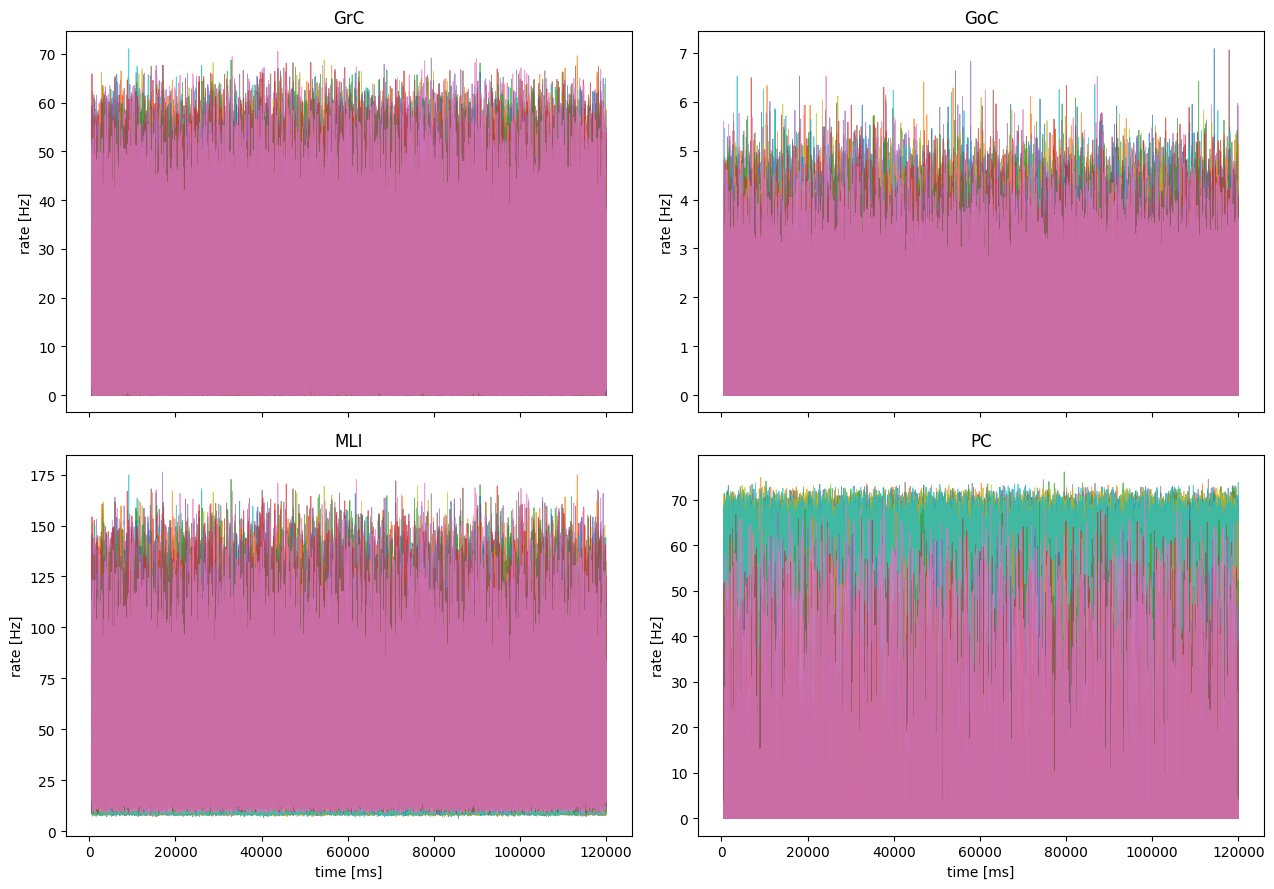

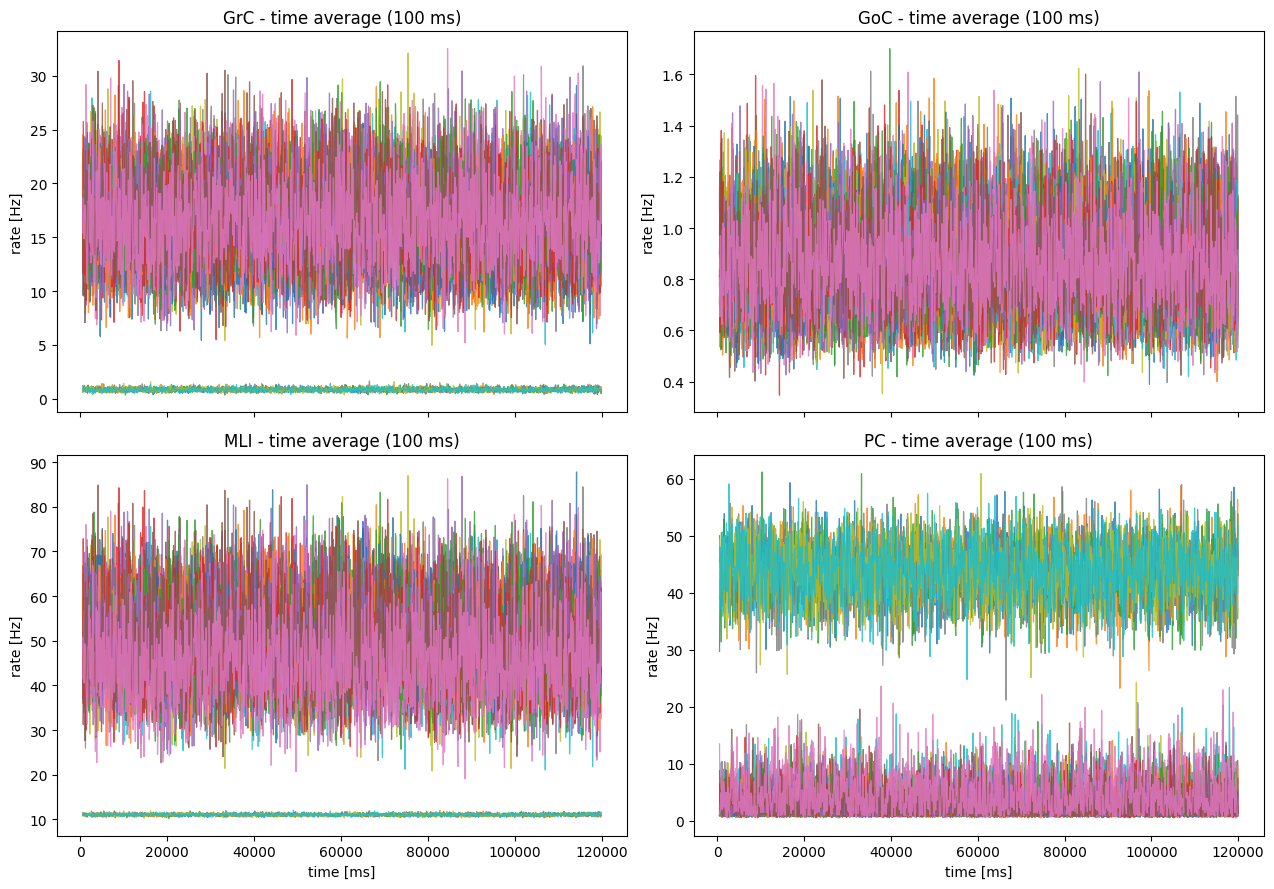

In [ ]:
def time_average(t, X, window=10.0):
    """Media su finestre non sovrapposte di `window` ms.
    t: (T,), X: (T, N) -> t_avg: (K,), X_avg: (K, N)"""
    t = np.asarray(t, dtype=float).ravel()
    X = np.asarray(X, dtype=float)
    dt = np.median(np.diff(t))
    n = int(round(window / dt))
    K = len(t) // n
    X_avg = X[:K * n].reshape(K, n, -1).mean(axis=1)
    t_avg = t[:K * n].reshape(K, n).mean(axis=1)
    return t_avg, X_avg


def plot_time_average(t, pops, window=100.0, labels=None, figsize=(14, 9)):
    """Come plot_raw_timeseries, ma sui dati mediati su finestre di `window` ms."""
    fig, ax = plt.subplots(2, 2, figsize=figsize, sharex=True)
    for a, (name, X) in zip(ax.ravel(), pops.items()):
        t_avg, X_avg = time_average(t, X, window)
        lines = a.plot(t_avg, X_avg, lw=0.9, alpha=0.8)
        a.set_title(f'{name} - time average ({window:g} ms)'); a.set_ylabel('rate [Hz]')
    for a in ax[-1]:
        a.set_xlabel('time [ms]')
    if labels is not None and len(labels) <= 20:
        fig.legend(lines, labels, loc='center right', fontsize=6)
    plt.tight_layout(rect=(0, 0, 0.92 if labels is not None else 1, 1))
    plt.show()

plot_time_average(t, pops, window=100.0, labels=connection.region_labels)

<function matplotlib.pyplot.title(label: 'str', fontdict: 'dict[str, Any] | None' = None, loc: "Literal['left', 'center', 'right'] | None" = None, pad: 'float | None' = None, *, y: 'float | None' = None, **kwargs) -> 'Text'>

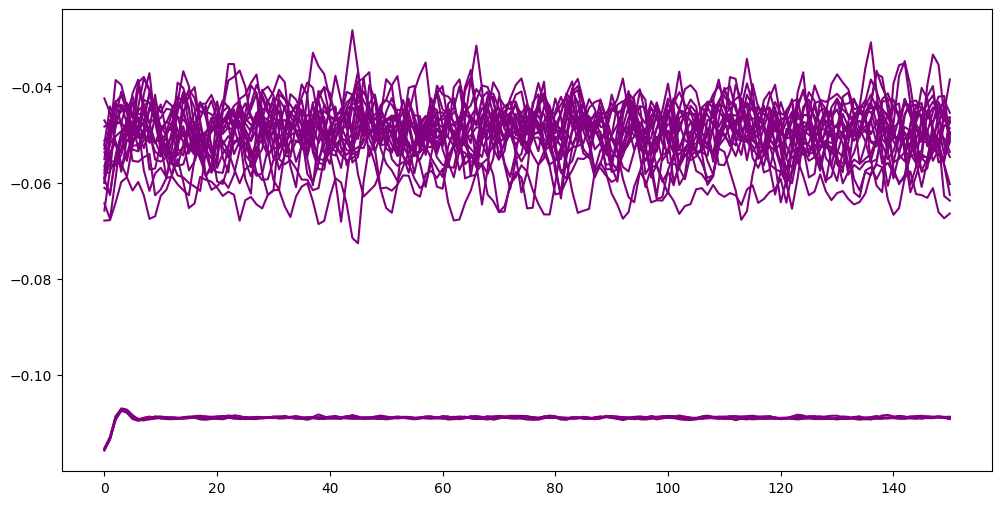

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(bolddata[15:], label='BOLD', color='purple')
plt.title

In [ ]:
np.shape(bolddata)

(166, 27)

In [ ]:
os.getcwd()

'/content'

In [ ]:
day_folder = '/content/drive/MyDrive/EITN_school_2026_MFM/Day5'
TR = 720
SC_pathname = 'curatedSC'
out_file = os.path.join(day_folder, 'cerebellum_zplus' + '.npz')
print(out_file)
np.savez(out_file,
         timeseries_data=tavgdata,
         timeseries_time=tavgtime,
         bold_data=bolddata,
         bold_time=boldtime,
         dt=simulator.integrator.dt,
         TR=TR,
         cond_speed=simulator.conduction_speed,
         conn_name=os.path.basename(SC_pathname))

/content/drive/MyDrive/EITN_school_2026_MFM/Day5/cerebellum_zplus.npz


In [ ]:
!ls

drive  sample_data
